In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd
import os

file_path = '/content/gdrive/My Drive/DAP391m/cleaned_healthcare_stroke_data.csv'

try:
    df = pd.read_csv(file_path)
    display(df.head())
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp tại đường dẫn: {file_path}")
    print("Đang kiểm tra nội dung thư mục...")
    my_drive_path = '/content/gdrive/My Drive' # Corrected path for My Drive
    if os.path.exists(my_drive_path):
        print(f"Nội dung của '{my_drive_path}':")
        for item in os.listdir(my_drive_path):
            print(item)
    else:
        print(f"Thư mục 'My Drive' không tồn tại ở {my_drive_path}. Vui lòng kiểm tra lại việc mount Google Drive.")

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,log_avg_glucose_level,log_bmi
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly smoked,1,5.436731,3.627004
1,51676,female,61.0,0,0,yes,self-employed,rural,202.21,28.1,never smoked,1,5.314240,3.370738
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never smoked,1,4.672081,3.511545
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,smokes,1,5.148831,3.566712
4,1665,female,79.0,1,0,yes,self-employed,rural,174.12,24.0,never smoked,1,5.165471,3.218876


PREPROCESSING

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# df = pd.read_csv("healthcare-dataset-stroke-data.csv")  # nếu chưa load

# drop id nếu có
if "id" in df.columns:
    df = df.drop(columns=["id"])

# tách X/y
X = df.drop(columns=["stroke"])
y = df["stroke"]

# split (rất quan trọng vì imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Stroke rate train:", y_train.mean(), " test:", y_test.mean())

Train: (4088, 12)  Test: (1022, 12)
Stroke rate train: 0.04867906066536203  test: 0.04892367906066536


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Nếu bạn có log features thì CHỐT 1 phiên bản:
# Option A: dùng original
numeric_features = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]

# Option B: dùng log (nếu bạn đã tạo log_avg_glucose_level, log_bmi)
# numeric_features = ["age", "log_avg_glucose_level", "log_bmi", "hypertension", "heart_disease"]

categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
print("Processed train shape:", X_train_processed.shape)

Processed train shape: (4088, 21)


TRAIN

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
from sklearn.metrics import roc_auc_score

y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", roc)

ROC-AUC: 0.8436831275720165


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, average_precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# L2 model
logreg_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear"
    ))
])

cv_results_l2 = cross_validate(
    logreg_l2,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("LogReg L2 ROC-AUC:", cv_results_l2["test_roc_auc"].mean())
print("LogReg L2 PR-AUC:", cv_results_l2["test_pr_auc"].mean())

LogReg L2 ROC-AUC: 0.8387474705983703
LogReg L2 PR-AUC: 0.19297371977524638


In [ ]:
logreg_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear"
    ))
])

cv_results_l1 = cross_validate(
    logreg_l1,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("LogReg L1 ROC-AUC:", cv_results_l1["test_roc_auc"].mean())
print("LogReg L1 PR-AUC:", cv_results_l1["test_pr_auc"].mean())

LogReg L1 ROC-AUC: 0.8387793160543804
LogReg L1 PR-AUC: 0.19292585974567045


In [ ]:
from sklearn.svm import SVC

svc_linear = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVC(
        kernel="linear",
        class_weight="balanced",
        probability=True  # để tính ROC-AUC & threshold sau
    ))
])

cv_results_svc_linear = cross_validate(
    svc_linear,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("SVC Linear ROC-AUC:", cv_results_svc_linear["test_roc_auc"].mean())
print("SVC Linear PR-AUC:", cv_results_svc_linear["test_pr_auc"].mean())

SVC Linear ROC-AUC: 0.8385641263597561
SVC Linear PR-AUC: 0.1970596484581368


In [ ]:
svc_rbf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True
    ))
])

cv_results_svc_rbf = cross_validate(
    svc_rbf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("SVC RBF ROC-AUC:", cv_results_svc_rbf["test_roc_auc"].mean())
print("SVC RBF PR-AUC:", cv_results_svc_rbf["test_pr_auc"].mean())

SVC RBF ROC-AUC: 0.7831848261861116
SVC RBF PR-AUC: 0.13603304745694983


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Fit lại LogReg L2 trên train
logreg_l2.fit(X_train, y_train)

y_proba_test = logreg_l2.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.5, 50)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.5
Best F1: 0.23529411764705882


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# threshold mặc định
y_pred_05 = (y_proba_test >= 0.50).astype(int)

print("Threshold = 0.5")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05))

# thử threshold thấp hơn
y_pred_03 = (y_proba_test >= 0.3).astype(int)

print("Threshold = 0.3")
print(confusion_matrix(y_test, y_pred_03))
print(classification_report(y_test, y_pred_03))

Threshold = 0.5
[[722 250]
 [ 10  40]]
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022

Threshold = 0.3
[[580 392]
 [  8  42]]
              precision    recall  f1-score   support

           0       0.99      0.60      0.74       972
           1       0.10      0.84      0.17        50

    accuracy                           0.61      1022
   macro avg       0.54      0.72      0.46      1022
weighted avg       0.94      0.61      0.72      1022



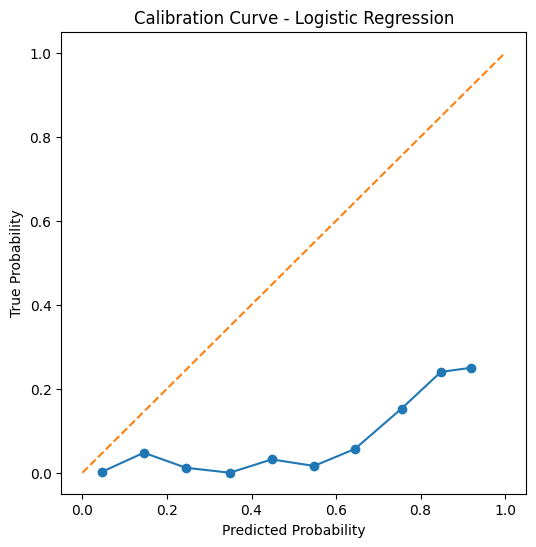

Brier Score: 0.16765481102348526


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Dùng xác suất từ LogReg
prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve - Logistic Regression")
plt.show()

print("Brier Score:", brier_score_loss(y_test, y_proba_test))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

dummy = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

cv_results_dummy = cross_validate(
    dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("Majority ROC-AUC:", cv_results_dummy["test_roc_auc"].mean())
print("Majority PR-AUC:", cv_results_dummy["test_pr_auc"].mean())

Majority ROC-AUC: 0.5
Majority PR-AUC: 0.0486788985883712


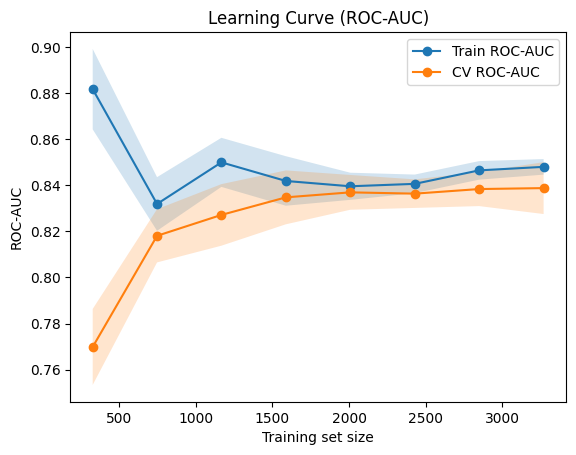

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# dùng model bạn chọn: logreg_l2 (Pipeline preprocess+LogReg)
train_sizes, train_scores, val_scores = learning_curve(
    logreg_l2,
    X_train, y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.plot(train_sizes, train_mean, marker='o', label="Train ROC-AUC")
plt.plot(train_sizes, val_mean, marker='o', label="CV ROC-AUC")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve (ROC-AUC)")
plt.legend()
plt.show()

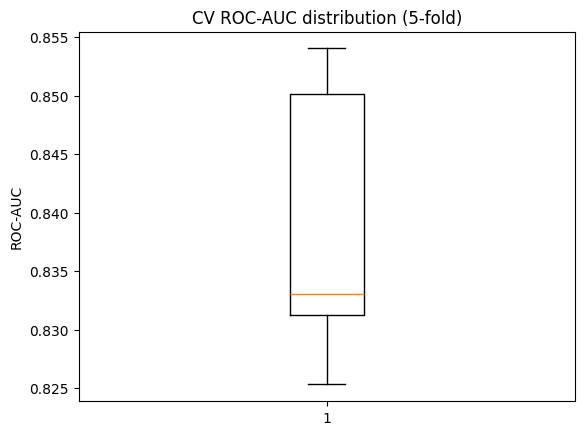

CV ROC-AUC mean±std: 0.8387474705983703 ± 0.01123206035417145


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logreg_l2, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

plt.boxplot(scores)
plt.ylabel("ROC-AUC")
plt.title("CV ROC-AUC distribution (5-fold)")
plt.show()

print("CV ROC-AUC mean±std:", scores.mean(), "±", scores.std())

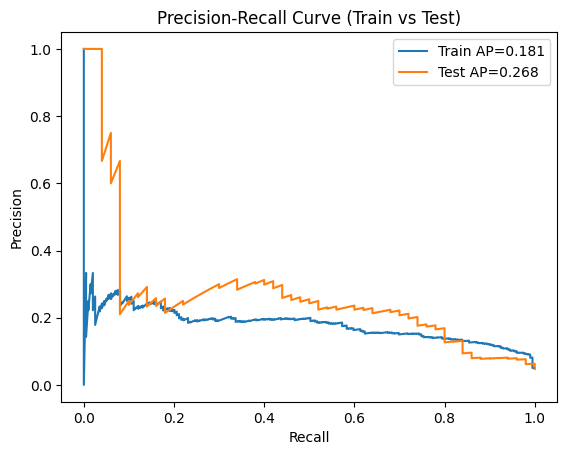

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# fit trên train
logreg_l2.fit(X_train, y_train)

# proba train/test
p_train = logreg_l2.predict_proba(X_train)[:,1]
p_test  = logreg_l2.predict_proba(X_test)[:,1]

prec_tr, rec_tr, _ = precision_recall_curve(y_train, p_train)
prec_te, rec_te, _ = precision_recall_curve(y_test,  p_test)

ap_tr = average_precision_score(y_train, p_train)
ap_te = average_precision_score(y_test,  p_test)

import matplotlib.pyplot as plt
plt.plot(rec_tr, prec_tr, label=f"Train AP={ap_tr:.3f}")
plt.plot(rec_te, prec_te, label=f"Test AP={ap_te:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Train vs Test)")
plt.legend()
plt.show()

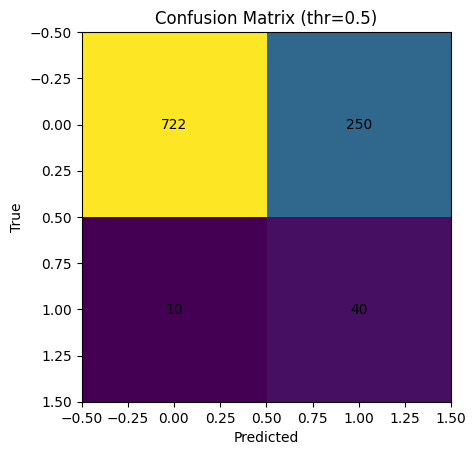

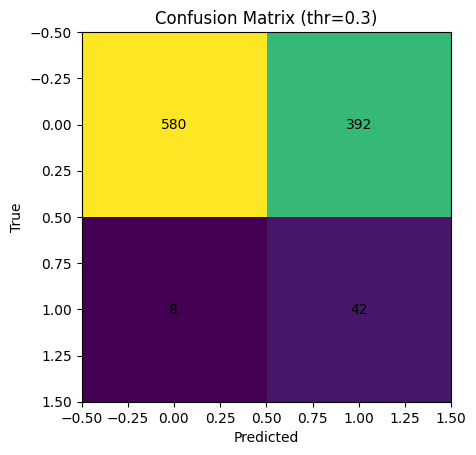

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_proba, thr, title):
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha='center', va='center')
    plt.show()

y_proba_test = logreg_l2.predict_proba(X_test)[:,1]
plot_cm(y_test, y_proba_test, 0.5, "Confusion Matrix (thr=0.5)")
plot_cm(y_test, y_proba_test, 0.3, "Confusion Matrix (thr=0.3)")

In [ ]:
# dùng model cuối cùng đã chọn
logreg_l2.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [ ]:
import pickle

# Save the trained model
filename = 'stroke_risk_model.pkl'
pickle.dump(logreg_l2, open(filename, 'wb'))

print(f"Model saved as {filename}")

Model saved as stroke_risk_model.pkl
